# 参照先特徴を除外した大会間汎化実験

目的:
- 大会間で分布差が出やすい参照先ベース特徴を削除すると、未知大会への汎化が改善するかを検証する。
- Baseline（従来除外）と NoRecipientRef（参照先関連を追加除外）を比較する。

In [44]:
import sys
import itertools
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from src.Rolepredicter.role_assignment import assign_roles_for_seer_by_divination,assign_roles_for_non_seer

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
CONFIG_PATH = PROJECT_ROOT / "config" / "training_config.json"
OUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "cross_tournament_generalization"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from src.pipelines.training_pipeline import load_training_config, get_data_paths

print(pd.DataFrame([
    {"key": "PROJECT_ROOT", "value": str(PROJECT_ROOT)},
    {"key": "CONFIG_PATH", "value": str(CONFIG_PATH)},
    {"key": "OUT_DIR", "value": str(OUT_DIR)},
]))

            key                                              value
0  PROJECT_ROOT  c:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定...
1   CONFIG_PATH  c:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定...
2       OUT_DIR  c:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定...


In [30]:
config = load_training_config(CONFIG_PATH)
data_paths = get_data_paths(config)
if len(data_paths) == 0:
    raise ValueError("No data_paths found in training_config.json")

frames = []
for p in data_paths:
    p_path = Path(p)
    df_raw = pd.read_csv(p)
    if "day" not in df_raw.columns or "role" not in df_raw.columns:
        print(f"skip {p_path.name}: missing day or role")
        continue
    df_raw["dataset_tag"] = p_path.stem
    frames.append(df_raw)

if not frames:
    raise ValueError("No valid data loaded.")

df_all = pd.concat(frames, ignore_index=True)

# day=1 に合わせて比較（既存分析と整合）
df_day1 = df_all[df_all["day"] == 1].copy()
if df_day1.empty:
    raise ValueError("No day=1 rows found.")

display(df_day1[["dataset_tag", "role"]].groupby("dataset_tag").agg(rows=("role", "size"), roles=("role", "nunique")))

✓ Data files selected:
  - all_feature_table_2025sp17_with_talks.csv
  - all_feature_table_2025summer_with_talks2.csv


,rows,roles
dataset_tag,,
all_feature_table_2025sp17_with_talks,530,4
all_feature_table_2025summer_with_talks2,595,4


In [31]:
BASE_DROP_COLS = [
    "id", "role", "source_file", "dataset_tag", "day", "role_encoded",
    "Est_id_Fact_role", "Est_id_Est_roles", "character_name",
    "agent_name", "combined_text", "seer_co_order"
]
META_RAW_COLS = [
    "True_Div_result_1", "True_Div_recepient_id_1",
    "True_Div_result_2", "True_Div_recepient_id_2",
    "exec_id", "attack_id"
]
LEAKAGE_DROP_COLS = config.get("leakage_drop_columns", [])

def build_drop_columns(df, mode="baseline"):
    id_sensitive = [
        c for c in df.columns
        if c == "Div_recepient_id"
        or c.startswith("Div_recepient_id_")
        or c == "Div_recipient_id"
        or c.startswith("Div_recipient_id_")
        or c.endswith("_id")
    ]

    drop_cols = set(BASE_DROP_COLS + META_RAW_COLS + LEAKAGE_DROP_COLS + id_sensitive)

    if mode == "no_recipient_ref":
        recipient_ref_cols = [
            c for c in df.columns
            if "recepient" in c.lower()
            or "recipient" in c.lower()
            or "_id_" in c
        ]
        drop_cols.update(recipient_ref_cols)

    return sorted(drop_cols)

for mode in ["baseline", "no_recipient_ref"]:
    dcols = build_drop_columns(df_day1, mode=mode)
    print(f"{mode}: drop={len(dcols)}")

baseline: drop=49
no_recipient_ref: drop=209


In [ ]:
ROLE_COUNTS_5P = {
    "POSSESSED": 1,
    "SEER": 1,
    "VILLAGER": 2,
    "WEREWOLF": 1,
}


def assign_roles_with_count_constraint(game_proba, class_names, role_counts):
    class_names = list(class_names)
    class_to_idx = {r: i for i, r in enumerate(class_names)}

    roles_pool = []
    for role_name, count in role_counts.items():
        if role_name in class_to_idx:
            roles_pool.extend([role_name] * int(count))

    if len(roles_pool) != game_proba.shape[0]:
        return np.argmax(game_proba, axis=1)

    best_perm = None
    best_score = -np.inf

    for perm in set(itertools.permutations(roles_pool)):
        score = 0.0
        for i, role_name in enumerate(perm):
            role_idx = class_to_idx[role_name]
            score += np.log(float(game_proba[i, role_idx]) + 1e-12)
        if score > best_score:
            best_score = score
            best_perm = perm

    if best_perm is None:
        return np.argmax(game_proba, axis=1)

    return np.array([class_to_idx[r] for r in best_perm], dtype=int)


def evaluate_cross_tournament_generalization(df, mode):
    df = df.copy()
    drop_cols = build_drop_columns(df, mode=mode)

    candidate_features = [c for c in df.columns if c not in drop_cols]
    X_all = df[candidate_features].apply(pd.to_numeric, errors="coerce")

    valid_features = [
        c for c in candidate_features
        if X_all[c].notna().sum() >= 20 and X_all[c].nunique(dropna=True) >= 2
    ]

    if len(valid_features) == 0:
        raise ValueError(f"No valid numeric features left in mode={mode}.")

    X = X_all[valid_features]
    y_raw = df["role"].astype(str)
    groups = df["dataset_tag"].astype(str)

    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    datasets = sorted(groups.unique())
    if len(datasets) < 2:
        raise ValueError("Need at least 2 dataset_tag values for cross-tournament validation.")

    num_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    pre = ColumnTransformer(
        transformers=[("num", num_pipe, valid_features)],
        remainder="drop"
    )

    fold_rows = []
    report_rows = []

    for test_ds in datasets:
        train_mask = groups != test_ds
        test_mask = groups == test_ds

        if train_mask.sum() < 50 or test_mask.sum() < 20:
            continue

        X_train_raw, X_test_raw = X.loc[train_mask], X.loc[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]

        X_train = pre.fit_transform(X_train_raw)
        X_test = pre.transform(X_test_raw)

        class_weights_train = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_train),
            y=y_train,
        )
        sample_weight = np.array([class_weights_train[label] for label in y_train])

        model = XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            tree_method="hist",
        )
        model.fit(X_train, y_train, sample_weight=sample_weight)

        y_pred_argmax = model.predict(X_test)
        proba_test = model.predict_proba(X_test)

        # game単位割り当て: source_file があればそれを利用、なければ5行ごとに擬似game化
        test_index = np.flatnonzero(test_mask.to_numpy())
        game_df = pd.DataFrame({"row_pos": np.arange(len(test_index))})

        if "source_file" in df.columns:
            game_df["game_id"] = df.iloc[test_index]["source_file"].astype(str).values
        else:
            game_df["game_id"] = (game_df["row_pos"] // 5).astype(str)

        y_pred_assigned = y_pred_argmax.copy()
        assigned_games = 0

        for _, g in game_df.groupby("game_id"):
            pos = g["row_pos"].to_numpy()
            if len(pos) != 5:
                continue
            y_pred_assigned[pos] = assign_roles_with_count_constraint(
                proba_test[pos],
                class_names=le.classes_,
                role_counts=ROLE_COUNTS_5P,
            )
            assigned_games += 1

        acc_argmax = accuracy_score(y_test, y_pred_argmax)
        f1_argmax = f1_score(y_test, y_pred_argmax, average="macro")

        acc_assigned = accuracy_score(y_test, y_pred_assigned)
        f1_assigned = f1_score(y_test, y_pred_assigned, average="macro")

        fold_rows.append({
            "mode": mode,
            "test_dataset": test_ds,
            "n_train": int(train_mask.sum()),
            "n_test": int(test_mask.sum()),
            "n_features": len(valid_features),
            "assigned_games": int(assigned_games),
            "accuracy_argmax": acc_argmax,
            "macro_f1_argmax": f1_argmax,
            "accuracy_assigned": acc_assigned,
            "macro_f1_assigned": f1_assigned,
        })

        c_report = classification_report(
            y_test,
            y_pred_assigned,
            target_names=le.classes_,
            output_dict=True,
            zero_division=0,
        )
        for role_name in le.classes_:
            if role_name in c_report:
                report_rows.append({
                    "mode": mode,
                    "test_dataset": test_ds,
                    "pred_type": "assigned",
                    "role": role_name,
                    "precision": c_report[role_name]["precision"],
                    "recall": c_report[role_name]["recall"],
                    "f1": c_report[role_name]["f1-score"],
                    "support": c_report[role_name]["support"],
                })

    fold_df = pd.DataFrame(fold_rows)
    report_df = pd.DataFrame(report_rows)

    return fold_df, report_df, valid_features

In [33]:
results = []
role_reports = []
feature_sets = {}

for mode in ["baseline", "no_recipient_ref"]:
    fold_df, report_df, valid_features = evaluate_cross_tournament_generalization(df_day1, mode=mode)
    if fold_df.empty:
        print(f"{mode}: no valid folds")
        continue

    feature_sets[mode] = valid_features
    results.append(fold_df)
    role_reports.append(report_df)

fold_result_df = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
role_result_df = pd.concat(role_reports, ignore_index=True) if role_reports else pd.DataFrame()

if fold_result_df.empty:
    raise ValueError("No fold results were generated.")

summary_df = (
    fold_result_df
    .groupby("mode", as_index=False)
    .agg(
        folds=("test_dataset", "count"),
        mean_accuracy_argmax=("accuracy_argmax", "mean"),
        mean_macro_f1_argmax=("macro_f1_argmax", "mean"),
        mean_accuracy_assigned=("accuracy_assigned", "mean"),
        mean_macro_f1_assigned=("macro_f1_assigned", "mean"),
        min_macro_f1_assigned=("macro_f1_assigned", "min"),
        max_macro_f1_assigned=("macro_f1_assigned", "max"),
    )
)

print("Cross-tournament summary (XGB + assignment)")
display(summary_df)

print("Fold details")
display(fold_result_df.sort_values(["mode", "test_dataset"]).reset_index(drop=True))

if not role_result_df.empty:
    role_summary = (
        role_result_df
        .groupby(["mode", "pred_type", "role"], as_index=False)
        .agg(mean_f1=("f1", "mean"), mean_recall=("recall", "mean"), mean_precision=("precision", "mean"))
        .sort_values(["mode", "pred_type", "mean_f1"], ascending=[True, True, False])
    )
    print("Role-level summary")
    display(role_summary)

Cross-tournament summary (XGB + assignment)


,mode,folds,mean_accuracy_argmax,mean_macro_f1_argmax,mean_accuracy_assigned,mean_macro_f1_assigned,min_macro_f1_assigned,max_macro_f1_assigned
0,baseline,2,0.331964,0.267737,0.311432,0.290456,0.282563,0.298349
1,no_recipient_ref,2,0.301625,0.251952,0.304416,0.267322,0.259434,0.275210


Fold details


,mode,test_dataset,n_train,n_test,n_features,assigned_games,accuracy_argmax,macro_f1_argmax,accuracy_assigned,macro_f1_assigned
0,baseline,all_feature_table_2025sp17_with_talks,595,530,135,106,0.369811,0.259627,0.316981,0.298349
1,baseline,all_feature_table_2025summer_with_talks2,530,595,135,119,0.294118,0.275848,0.305882,0.282563
2,no_recipient_ref,all_feature_table_2025sp17_with_talks,595,530,19,106,0.352830,0.260507,0.296226,0.259434
3,no_recipient_ref,all_feature_table_2025summer_with_talks2,530,595,19,119,0.250420,0.243396,0.312605,0.275210


Role-level summary


,mode,pred_type,role,mean_f1,mean_recall,mean_precision
2,baseline,assigned,VILLAGER,0.395335,0.395335,0.395335
1,baseline,assigned,SEER,0.310607,0.310607,0.310607
3,baseline,assigned,WEREWOLF,0.249723,0.249723,0.249723
0,baseline,assigned,POSSESSED,0.206160,0.206160,0.206160
6,no_recipient_ref,assigned,VILLAGER,0.452791,0.452791,0.452791
5,no_recipient_ref,assigned,SEER,0.239258,0.239258,0.239258
7,no_recipient_ref,assigned,WEREWOLF,0.220905,0.220905,0.220905
4,no_recipient_ref,assigned,POSSESSED,0.156334,0.156334,0.156334


In [34]:
out_fold = OUT_DIR / "cross_tournament_fold_results.csv"
out_summary = OUT_DIR / "cross_tournament_summary.csv"
out_role = OUT_DIR / "cross_tournament_role_results.csv"
out_feature_diff = OUT_DIR / "feature_set_diff_baseline_vs_no_recipient_ref.csv"

fold_result_df.to_csv(out_fold, index=False)
summary_df.to_csv(out_summary, index=False)
if 'role_result_df' in globals() and not role_result_df.empty:
    role_result_df.to_csv(out_role, index=False)

baseline_feats = set(feature_sets.get("baseline", []))
strict_feats = set(feature_sets.get("no_recipient_ref", []))
removed_feats = sorted(list(baseline_feats - strict_feats))
added_feats = sorted(list(strict_feats - baseline_feats))

feat_diff_df = pd.DataFrame({
    "removed_in_no_recipient_ref": pd.Series(removed_feats),
    "added_in_no_recipient_ref": pd.Series(added_feats)
})
feat_diff_df.to_csv(out_feature_diff, index=False)

print(f"Saved: {out_fold}")
print(f"Saved: {out_summary}")
if 'role_result_df' in globals() and not role_result_df.empty:
    print(f"Saved: {out_role}")
print(f"Saved: {out_feature_diff}")

Saved: c:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定_GitHub\notebooks\outputs\cross_tournament_generalization\cross_tournament_fold_results.csv
Saved: c:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定_GitHub\notebooks\outputs\cross_tournament_generalization\cross_tournament_summary.csv
Saved: c:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定_GitHub\notebooks\outputs\cross_tournament_generalization\cross_tournament_role_results.csv
Saved: c:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定_GitHub\notebooks\outputs\cross_tournament_generalization\feature_set_diff_baseline_vs_no_recipient_ref.csv


## 解釈の目安
- まず summary の mean_macro_f1 を baseline と no_recipient_ref で比較する。
- no_recipient_ref の方が高ければ、参照先依存を減らすことで大会間汎化が改善した可能性が高い。
- 逆に低下する場合は、参照先情報のうち有益な部分まで落としているため、条件付きで除外範囲を緩める。

## 大会依存の特徴量を特定する

このセクションでは day=1 データを使い、特徴量ごとに次を計算します。
- `tournament_f_score`: `dataset_tag` を識別しやすいほど高い（大会依存が強い）
- `max_pairwise_smd`: 大会間の平均差（標準化差）が大きいほど分布差が強い

2つを標準化して合算した `dependency_score` で大会依存特徴を順位付けします。

In [35]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

# baseline の前処理設定を使って大会依存を測定
dep_drop_cols = build_drop_columns(df_day1, mode="baseline")

dep_candidate_features = [c for c in df_day1.columns if c not in dep_drop_cols]
X_dep_raw = df_day1[dep_candidate_features].apply(pd.to_numeric, errors="coerce")

# 低品質列を除去
valid_dep_features = [
    c for c in dep_candidate_features
    if X_dep_raw[c].notna().sum() >= 20 and X_dep_raw[c].nunique(dropna=True) >= 2
]

if len(valid_dep_features) == 0:
    raise ValueError("No valid features found for tournament dependency analysis.")

X_dep = X_dep_raw[valid_dep_features].fillna(0)

tag_encoder = LabelEncoder()
y_tournament = tag_encoder.fit_transform(df_day1["dataset_tag"].astype(str))

if len(np.unique(y_tournament)) < 2:
    raise ValueError("Need at least 2 tournaments (dataset_tag) for dependency analysis.")

# 1) 大会識別のしやすさ（ANOVA F値）
t_f_score, _ = f_classif(X_dep, y_tournament)

# 2) 大会間分布差（最大ペアワイズSMD）
unique_tags = sorted(df_day1["dataset_tag"].astype(str).unique())

def _smd(a, b):
    a = pd.to_numeric(a, errors="coerce").dropna().to_numpy()
    b = pd.to_numeric(b, errors="coerce").dropna().to_numpy()
    if len(a) < 5 or len(b) < 5:
        return np.nan
    va = np.var(a, ddof=1)
    vb = np.var(b, ddof=1)
    pooled = np.sqrt((va + vb) / 2.0) if (va + vb) > 0 else np.nan
    if not np.isfinite(pooled) or pooled <= 0:
        return np.nan
    return float((np.mean(a) - np.mean(b)) / pooled)

max_pairwise_smd = []
for feat in valid_dep_features:
    pair_abs_smd = []
    for i in range(len(unique_tags)):
        for j in range(i + 1, len(unique_tags)):
            t1 = unique_tags[i]
            t2 = unique_tags[j]
            s1 = df_day1.loc[df_day1["dataset_tag"].astype(str) == t1, feat]
            s2 = df_day1.loc[df_day1["dataset_tag"].astype(str) == t2, feat]
            smd_val = _smd(s1, s2)
            if np.isfinite(smd_val):
                pair_abs_smd.append(abs(smd_val))
    max_pairwise_smd.append(np.max(pair_abs_smd) if pair_abs_smd else np.nan)

# スコア統合
smd_series = pd.Series(max_pairwise_smd, index=valid_dep_features, dtype=float)
f_series = pd.Series(t_f_score, index=valid_dep_features, dtype=float)

def _zscore_safe(s):
    s = s.astype(float)
    std = s.std(ddof=0)
    if not np.isfinite(std) or std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

dependency_df = pd.DataFrame({
    "feature": valid_dep_features,
    "tournament_f_score": f_series.values,
    "max_pairwise_smd": smd_series.values,
})
dependency_df["z_f_score"] = _zscore_safe(dependency_df["tournament_f_score"]) 
dependency_df["z_max_pairwise_smd"] = _zscore_safe(dependency_df["max_pairwise_smd"].fillna(0.0))
dependency_df["dependency_score"] = dependency_df["z_f_score"] + dependency_df["z_max_pairwise_smd"]

dependency_df = dependency_df.sort_values("dependency_score", ascending=False).reset_index(drop=True)

print("Top tournament-dependent features")
display(dependency_df.head(30))

if "feature_sets" in globals() and "baseline" in feature_sets:
    baseline_set = set(feature_sets["baseline"])
    dep_in_baseline_df = dependency_df[dependency_df["feature"].isin(baseline_set)].copy()
    print("Top tournament-dependent features within baseline feature set")
    display(dep_in_baseline_df.head(30))

Top tournament-dependent features


,feature,tournament_f_score,max_pairwise_smd,z_f_score,z_max_pairwise_smd,dependency_score
0,seer_co_num,2389.733732,2.834050,10.981539,6.413310,17.394848
1,day1_vote_id_ReqDiscuss,442.348258,1.196151,1.793467,1.851755,3.645222
2,ReqDiscuss,427.770715,1.204673,1.724688,1.875488,3.600175
3,Agr_id_ReqDiscuss,101.835286,1.475836,0.186873,2.630679,2.817552
4,Sus_recepient_id_ReqDiscuss,234.566511,1.187149,0.813120,1.826685,2.639805
5,Vote_recepient_id_ReqDiscuss,20.692705,1.406660,-0.195971,2.438024,2.242053
6,day1_vote_id_calm,264.618475,0.938547,0.954910,1.134326,2.089235
7,Dis_id_ReqDiscuss,44.301275,1.296073,-0.084582,2.130037,2.045455
8,calm,254.853932,0.927349,0.908839,1.103140,2.011979
9,Est_id_ReqDiscuss,126.699786,1.100196,0.304188,1.584520,1.888707


Top tournament-dependent features within baseline feature set


,feature,tournament_f_score,max_pairwise_smd,z_f_score,z_max_pairwise_smd,dependency_score
0,seer_co_num,2389.733732,2.834050,10.981539,6.413310,17.394848
1,day1_vote_id_ReqDiscuss,442.348258,1.196151,1.793467,1.851755,3.645222
2,ReqDiscuss,427.770715,1.204673,1.724688,1.875488,3.600175
3,Agr_id_ReqDiscuss,101.835286,1.475836,0.186873,2.630679,2.817552
4,Sus_recepient_id_ReqDiscuss,234.566511,1.187149,0.813120,1.826685,2.639805
5,Vote_recepient_id_ReqDiscuss,20.692705,1.406660,-0.195971,2.438024,2.242053
6,day1_vote_id_calm,264.618475,0.938547,0.954910,1.134326,2.089235
7,Dis_id_ReqDiscuss,44.301275,1.296073,-0.084582,2.130037,2.045455
8,calm,254.853932,0.927349,0.908839,1.103140,2.011979
9,Est_id_ReqDiscuss,126.699786,1.100196,0.304188,1.584520,1.888707


In [36]:
out_dep = OUT_DIR / "tournament_dependency_features.csv"
out_dep_baseline = OUT_DIR / "tournament_dependency_features_in_baseline.csv"

dependency_df.to_csv(out_dep, index=False)
print(f"Saved: {out_dep}")

if "dep_in_baseline_df" in globals() and not dep_in_baseline_df.empty:
    dep_in_baseline_df.to_csv(out_dep_baseline, index=False)
    print(f"Saved: {out_dep_baseline}")

Saved: c:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定_GitHub\notebooks\outputs\cross_tournament_generalization\tournament_dependency_features.csv
Saved: c:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定_GitHub\notebooks\outputs\cross_tournament_generalization\tournament_dependency_features_in_baseline.csv


## 大会依存度の高い特徴量を段階的に除外して汎化性能を評価・可視化する
- dependency_scoreの高い順に特徴量を除外し、cross-tournament評価（macro F1）を自動で回します。
- 除外数ごとに性能を記録し、グラフで可視化します。
- これにより「どこまで除外すれば未知大会への汎化性能が最大化されるか」を把握できます。

In [48]:
# dependency_score順に特徴量を除外しながらcross-tournament評価を自動で回す
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# tqdmが使えない場合はrangeで代用
exclude_steps = list(range(0, min(105, len(dependency_df)), 5))
if exclude_steps[-1] != len(dependency_df)-1:
    exclude_steps.append(len(dependency_df)-1)
results_exclude = []

baseline_feats = list(feature_sets['baseline']) if 'feature_sets' in globals() and 'baseline' in feature_sets else list(dependency_df['feature'])
dep_sorted = dependency_df.set_index('feature').loc[baseline_feats].sort_values('dependency_score', ascending=False).index.tolist()

for n_exclude in exclude_steps:
    # 除外する特徴量リスト
    exclude_feats = set(dep_sorted[:n_exclude])
    use_feats = [f for f in baseline_feats if f not in exclude_feats]
    
    # データ作成
    X = df_day1[use_feats].apply(pd.to_numeric, errors='coerce')
    y_raw = df_day1['role'].astype(str)
    groups = df_day1['dataset_tag'].astype(str)
    
    # 低品質列除去
    valid_feats = [c for c in use_feats if X[c].notna().sum() >= 20 and X[c].nunique(dropna=True) >= 2]
    if len(valid_feats) == 0:
        continue
    X = X[valid_feats]
    
    # cross-tournament評価（foldごとに）
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    datasets = sorted(groups.unique())
    num_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
    pre = ColumnTransformer([('num', num_pipe, valid_feats)], remainder='drop')
    
    macro_f1s = []
    for test_ds in datasets:
        train_mask = groups != test_ds
        test_mask = groups == test_ds
        if train_mask.sum() < 50 or test_mask.sum() < 20:
            continue
        X_train = pre.fit_transform(X.loc[train_mask])
        X_test = pre.transform(X.loc[test_mask])
        y_train, y_test = y[train_mask], y[test_mask]
        class_weights_train = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        sample_weight = np.array([class_weights_train[label] for label in y_train])
        model = XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, tree_method='hist')
        model.fit(X_train, y_train, sample_weight=sample_weight)
        proba_test = model.predict_proba(X_test)
        y_pred_argmax = model.predict(X_test)
        # 割り当て制約適用
        test_index = np.flatnonzero(test_mask.to_numpy())
        game_df = pd.DataFrame({'row_pos': np.arange(len(test_index))})
        if 'source_file' in df_day1.columns:
            game_df['game_id'] = df_day1.iloc[test_index]['source_file'].astype(str).values
        else:
            game_df['game_id'] = (game_df['row_pos'] // 5).astype(str)
        y_pred_assigned = y_pred_argmax.copy()
        for _, g in game_df.groupby('game_id'):
            pos = g['row_pos'].to_numpy()
            if len(pos) != 5: continue
            y_pred_assigned[pos] = assign_roles_with_count_constraint(proba_test[pos], class_names=le.classes_, role_counts=ROLE_COUNTS_5P)
        macro_f1 = f1_score(y_test, y_pred_assigned, average='macro')
        macro_f1s.append(macro_f1)
    if macro_f1s:
        results_exclude.append({'n_exclude': n_exclude, 'n_features': len(valid_feats), 'macro_f1_mean': np.mean(macro_f1s), 'macro_f1_min': np.min(macro_f1s), 'macro_f1_max': np.max(macro_f1s)})

results_exclude_df = pd.DataFrame(results_exclude)
display(results_exclude_df)

,n_exclude,n_features,macro_f1_mean,macro_f1_min,macro_f1_max
0,0,135,0.290456,0.282563,0.298349
1,5,130,0.291001,0.279481,0.302521
2,10,125,0.283777,0.281840,0.285714
3,15,120,0.274333,0.272406,0.276261
4,20,115,0.272049,0.259434,0.284664
5,25,110,0.284396,0.254717,0.314076
6,30,105,0.278490,0.252358,0.304622
7,35,100,0.269497,0.251179,0.287815
8,40,95,0.293166,0.280660,0.305672
9,45,90,0.305826,0.291274,0.320378


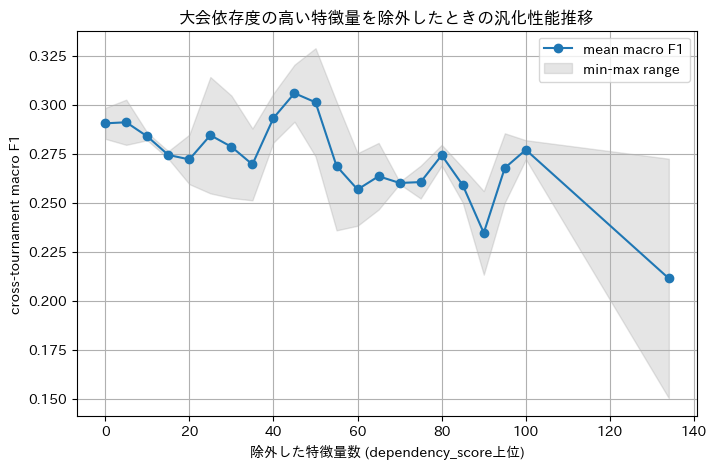

In [49]:
# 除外数ごとのmacro F1推移をグラフ化
import matplotlib.pyplot as plt
import japanize_matplotlib
plt.figure(figsize=(8,5))
plt.plot(results_exclude_df['n_exclude'], results_exclude_df['macro_f1_mean'], marker='o', label='mean macro F1')
plt.fill_between(results_exclude_df['n_exclude'], results_exclude_df['macro_f1_min'], results_exclude_df['macro_f1_max'], color='gray', alpha=0.2, label='min-max range')
plt.xlabel('除外した特徴量数 (dependency_score上位)')
plt.ylabel('cross-tournament macro F1')
plt.title('大会依存度の高い特徴量を除外したときの汎化性能推移')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# 85次元（n_exclude=50）の特徴量で各役職ごとのcross-tournament評価結果を表示
n_exclude_target = 50
exclude_feats = set(dep_sorted[:n_exclude_target])
use_feats = [f for f in baseline_feats if f not in exclude_feats]

X = df_day1[use_feats].apply(pd.to_numeric, errors='coerce')
y_raw = df_day1['role'].astype(str)
groups = df_day1['dataset_tag'].astype(str)

valid_feats = [c for c in use_feats if X[c].notna().sum() >= 20 and X[c].nunique(dropna=True) >= 2]
X = X[valid_feats]

le = LabelEncoder()
y = le.fit_transform(y_raw)
datasets = sorted(groups.unique())
num_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
pre = ColumnTransformer([('num', num_pipe, valid_feats)], remainder='drop')

role_reports = []
for test_ds in datasets:
    train_mask = groups != test_ds
    test_mask = groups == test_ds
    if train_mask.sum() < 50 or test_mask.sum() < 20:
        continue
    X_train = pre.fit_transform(X.loc[train_mask])
    X_test = pre.transform(X.loc[test_mask])
    y_train, y_test = y[train_mask], y[test_mask]
    class_weights_train = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    sample_weight = np.array([class_weights_train[label] for label in y_train])
    model = XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, tree_method='hist')
    model.fit(X_train, y_train, sample_weight=sample_weight)
    proba_test = model.predict_proba(X_test)
    y_pred_argmax = model.predict(X_test)
    # 割り当て制約適用
    test_index = np.flatnonzero(test_mask.to_numpy())
    game_df = pd.DataFrame({'row_pos': np.arange(len(test_index))})
    if 'source_file' in df_day1.columns:
        game_df['game_id'] = df_day1.iloc[test_index]['source_file'].astype(str).values
    else:
        game_df['game_id'] = (game_df['row_pos'] // 5).astype(str)
    y_pred_assigned = y_pred_argmax.copy()
    for _, g in game_df.groupby('game_id'):
        pos = g['row_pos'].to_numpy()
        if len(pos) != 5: continue
        y_pred_assigned[pos] = assign_roles_with_count_constraint(proba_test[pos], class_names=le.classes_, role_counts=ROLE_COUNTS_5P)
    c_report = classification_report(y_test, y_pred_assigned, target_names=le.classes_, output_dict=True, zero_division=0)
    for role_name in le.classes_:
        if role_name in c_report:
            role_reports.append({
                'test_dataset': test_ds,
                'role': role_name,
                'precision': c_report[role_name]['precision'],
                'recall': c_report[role_name]['recall'],
                'f1': c_report[role_name]['f1-score'],
                'support': c_report[role_name]['support'],
            })

role_result_df_85 = pd.DataFrame(role_reports)
role_summary_85 = (
    role_result_df_85.groupby(['role'], as_index=False)
    .agg(mean_f1=('f1', 'mean'), mean_recall=('recall', 'mean'), mean_precision=('precision', 'mean'), total_support=('support', 'sum'))
    .sort_values(['mean_f1'], ascending=False)
    .reset_index(drop=True)
    )
print('85次元（n_exclude=50）での各役職ごとのcross-tournament評価（平均）')
display(role_summary_85)

85次元（n_exclude=50）での各役職ごとのcross-tournament評価（平均）


,role,mean_f1,mean_recall,mean_precision,total_support
0,VILLAGER,0.431822,0.431822,0.431822,450.0
1,SEER,0.345767,0.345767,0.345767,225.0
2,WEREWOLF,0.224076,0.224076,0.224076,225.0
3,POSSESSED,0.203068,0.203068,0.203068,225.0


In [40]:
# 85次元（n_exclude=50）の特徴量セット（use_feats）を表示
print(f"85次元特徴量セット（n_exclude=50）: {len(use_feats)} features")
print(use_feats)

85次元特徴量セット（n_exclude=50）: 85 features
['ReqListen', 'Req(CO)', 'Admiration', 'Wait', 'contradiction', 'difficult', 'confused', 'Exe', 'Req(V)', 'Req(T)', 'IF', 'Fact', 'day1_vote_id_Req(CO)', 'day1_vote_id_Req(V)', 'day1_vote_id_Req(T)', 'day1_vote_id_Admiration', 'day1_vote_id_Wait', 'day1_vote_id_contradiction', 'day1_vote_id_confused', 'day1_vote_id_IF', 'day1_vote_id_Fact', 'Sus_recepient_id_ReqListen', 'Sus_recepient_id_Req(CO)', 'Sus_recepient_id_Req(V)', 'Sus_recepient_id_Admiration', 'Sus_recepient_id_Wait', 'Sus_recepient_id_contradiction', 'Sus_recepient_id_confused', 'Sus_recepient_id_IF', 'Sus_recepient_id_Fact', 'Vote_recepient_id_Req(CO)', 'Vote_recepient_id_Req(V)', 'Vote_recepient_id_Req(T)', 'Vote_recepient_id_Admiration', 'Vote_recepient_id_Wait', 'Vote_recepient_id_contradiction', 'Vote_recepient_id_difficult', 'Vote_recepient_id_confused', 'Vote_recepient_id_Sus', 'Vote_recepient_id_IF', 'Vote_recepient_id_Fact', 'Fact_recepient_id_Req(CO)', 'Fact_recepient_id_Req(V